In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
import skimage as ski
import os
from joblib import Parallel, delayed
import warnings
from matplotlib.colors import LinearSegmentedColormap,LogNorm
import matplotlib.ticker as ticker
from skimage import filters, exposure
import cmcrameri.cm as cmc
from scipy.ndimage import uniform_filter
from sklearn.linear_model import LinearRegression
import alphashape
from scipy.interpolate import splprep, splev
#ignore warnings
warnings.filterwarnings("ignore")


In [ ]:
#import chick nuclei features
chick_cells = pd.read_excel("S4_Data.xlsx")
#import mouse nuclei features
mouse_cells = pd.read_excel("S1_Data.xlsx", sheet_name='Wt_E8.5_data')

# Select only the cells that are somite stage 4
SP_4_mouse = mouse_cells[mouse_cells['SP'] == 4]

#### View slices through epiblast labelled vs non labelled

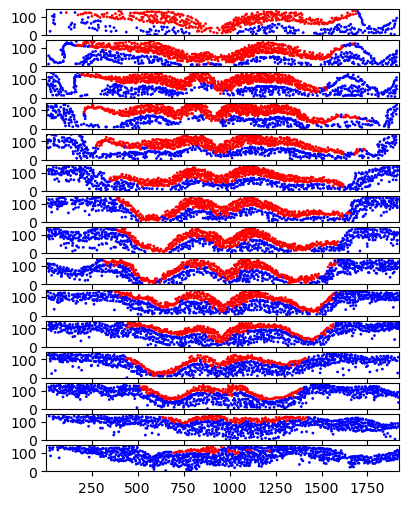

In [ ]:
def plot_slices(embryo_1, clus):
    """
    Plot slices of the embryo data showing the outcome of the epiblast prediction.
    Args:
        embryo_1 (DataFrame): DataFrame containing the embryo data.
        clus (str): Column name for the clustering prediction.
    """

    embryo_1['Z'] = (embryo_1['Z'] * -1) + embryo_1['Z'].max()  # Invert Z axis

    # Create a sequence of X values to slice through the embryo
    sequence = np.arange(0, embryo_1['X'].max(), 200 )  # Scale step size too
    buffer = 20   # Scale buffer size

    # Create a colormap for the scatter plot
    cmap = LinearSegmentedColormap.from_list('mycmap', ['blue', 'red'])

    # Create a figure with subplots for each slice
    fig, ax = plt.subplots(len(sequence), 1, figsize=(10, 6))

    for i, s in enumerate(sequence):
        data = embryo_1[(embryo_1['X'] > s) & (embryo_1['X'] < s + buffer)]
        ax[i].scatter(data['Y'], data['Z'], 
                      c=data[clus], cmap=cmap,
                      vmin=0, vmax=embryo_1[clus].max(), s=1)
        ax[i].set_aspect('equal', 'box')
        ax[i].set_xlim(embryo_1['Y'].min(), embryo_1['Y'].max())
        ax[i].set_ylim(embryo_1['Z'].min(), embryo_1['Z'].max())

plot_slices(chick_cells.loc[chick_cells['embryo'] == 1], 'epi_prediction')

#### T/Sox2 positive cells plot

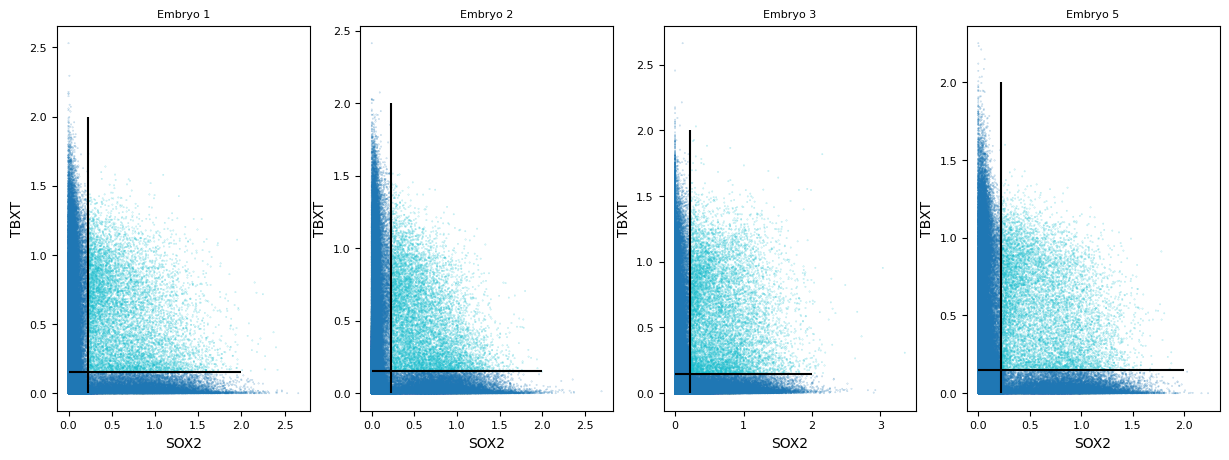

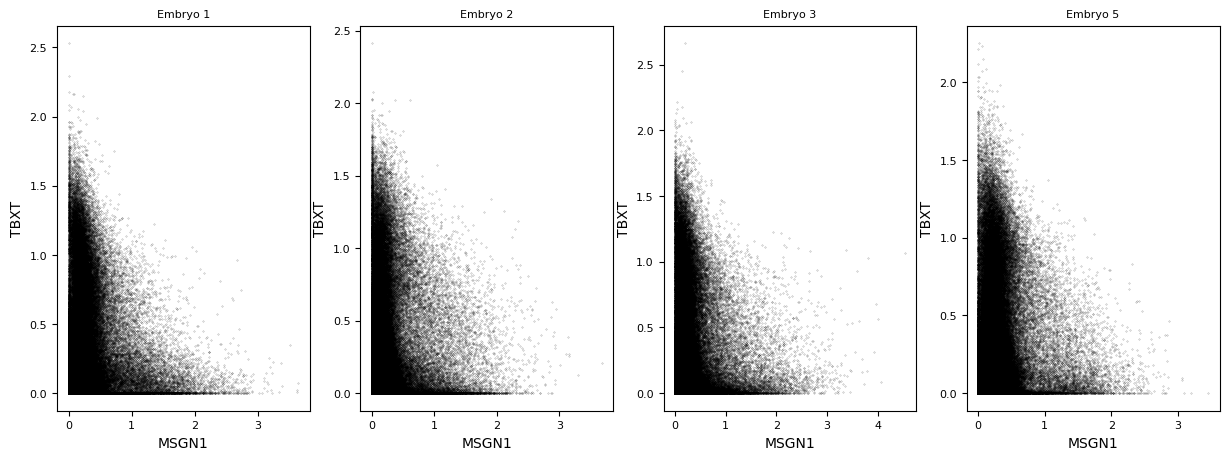

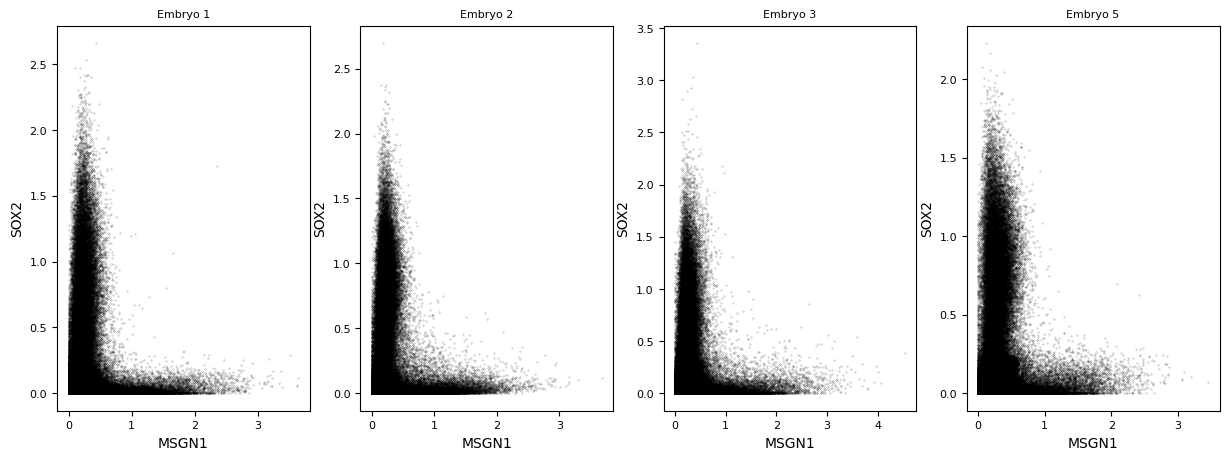

In [ ]:
#Set all negative values to 0
chick_cells.loc[chick_cells['MSGN1'] < 0, 'MSGN1'] = 0
chick_cells.loc[chick_cells['SOX2'] < 0, 'SOX2'] = 0
chick_cells.loc[chick_cells['TBXT'] < 0, 'TBXT'] = 0

# Set thresholds for TBXT and SOX2 based on density plots
Sox2_thresh = 0.22
TBXT_Thresh = 0.15

# Create a new column to indicate TBXT and SOX2 positive cells
chick_cells['TBXT_SOX2_pos'] = (chick_cells['TBXT'] > TBXT_Thresh) & (chick_cells['SOX2'] > Sox2_thresh)    

#scramble the row order for unbiased visualization
chick_cells = chick_cells.sample(frac=1)

# Plotting the TBXT and SOX2 expression in chick cells
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
for i, embryo in enumerate((1,2,3,5)):
    ax[i].scatter(chick_cells[chick_cells['embryo'] == embryo]['SOX2'], chick_cells[chick_cells['embryo'] == embryo]['TBXT'], c=chick_cells[chick_cells['embryo'] == embryo]['TBXT_SOX2_pos'], cmap='tab10', s = 0.05, alpha=0.5)
    ax[i].set_xlabel('SOX2')
    ax[i].set_ylabel('TBXT')
    ax[i].set_title(f'Embryo {embryo}')
    ax[i].hlines(TBXT_Thresh, 0, 2, color='black')
    ax[i].vlines(Sox2_thresh, 0, 2, color='black')

# Plotting the MSGN1 expression in chick cells
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
for i, embryo in enumerate((1,2,3,5)):
    ax[i].scatter(chick_cells[chick_cells['embryo'] == embryo]['MSGN1'], chick_cells[chick_cells['embryo'] == embryo]['TBXT'], c = 'black', s = 0.05, alpha=0.5)
    ax[i].set_xlabel('MSGN1')
    ax[i].set_ylabel('TBXT')
    ax[i].set_title(f'Embryo {embryo}')

# Plotting the MSGN1 expression in chick cells against SOX2
fig, ax = plt.subplots(1, 4, figsize=(15, 5))
for i, embryo in enumerate((1,2,3,5)):
    ax[i].scatter(chick_cells[chick_cells['embryo'] == embryo]['MSGN1'], chick_cells[chick_cells['embryo'] == embryo]['SOX2'], c = 'black', s = 0.05, alpha=0.5)
    ax[i].set_xlabel('MSGN1')
    ax[i].set_ylabel('SOX2')
    ax[i].set_title(f'Embryo {embryo}')



## Plot hexbin for all embryos and Sox2/TBXT


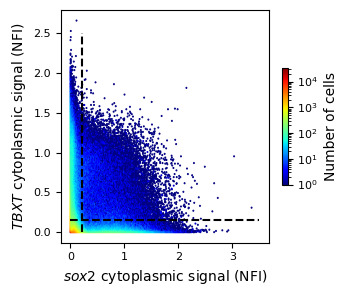

In [ ]:
small = 8
medium = 10
large = 12

plt.rc('font', size=small)          # controls default text sizes
plt.rc('axes', titlesize=small)     # fontsize of the axes title
plt.rc('axes', labelsize=medium)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=small)    # fontsize of the tick labels
plt.rc('ytick', labelsize=small)    # fontsize of the tick labels
plt.rc('legend', fontsize=small)    # legend fontsize
plt.rc('figure', titlesize=large)  # fontsize of the figure title


fig, ax = plt.subplots(1,1, figsize=(3.5,3))

#set 0 to empty
ax.hexbin(chick_cells['SOX2'], chick_cells['TBXT'], gridsize=300, cmap='jet', norm=LogNorm() )
ax.set_xlabel('$sox2$ cytoplasmic signal (NFI)')
ax.set_ylabel('$TBXT$ cytoplasmic signal (NFI)')

#plot colorbar
cb = plt.colorbar(ax.collections[0], ax=ax, label='Number of cells', shrink = 0.5)

ax.hlines(TBXT_Thresh, 0, 3.5, color='black', linestyle='--')
ax.vlines(Sox2_thresh, 0, 2.5, color='black', linestyle='--')

plt.tight_layout()


#### Size comparison of mouse and chick epiblasts

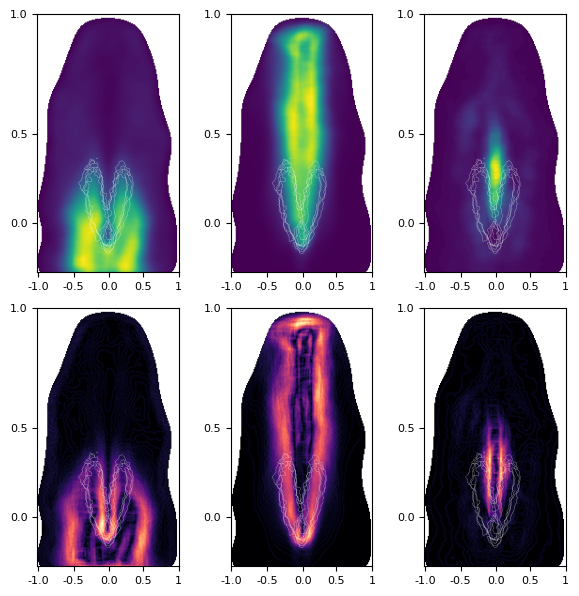

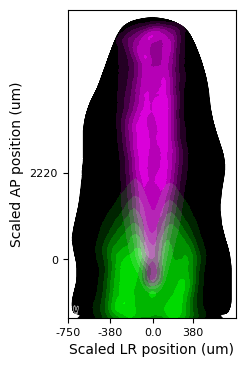

In [ ]:
# Filter epiblast cells
epi_nuc = chick_cells[chick_cells['epi_prediction'] == 1]

# Normalize MSGN1 and threshold\
msgn1_thresh = 0.3
epi_nuc['MSGN1'] -= msgn1_thresh
epi_nuc.loc[epi_nuc['MSGN1'] < 0.01, 'MSGN1'] = 0.01

# Scale position coordinates
ant_limit = abs(epi_nuc['Scaled_Rel_AP_position'].min())
LR_mid = abs(epi_nuc['Scaled_Rel_LR_position'].min())

#Store the length scales
PS_length = epi_nuc['Scaled_Rel_AP_position'].max()
LR_length = epi_nuc['Scaled_Rel_LR_position'].max() + abs(epi_nuc['Scaled_Rel_LR_position'].min())

epi_nuc['Scaled_Rel_AP_position'] -= epi_nuc['Scaled_Rel_AP_position'].min()
epi_nuc['Scaled_Rel_LR_position'] -= epi_nuc['Scaled_Rel_LR_position'].min()

# Configuration settings
x_col, y_col = 'Scaled_Rel_LR_position', 'Scaled_Rel_AP_position'
channels = ['SOX2', 'TBXT', 'MSGN1']
embryos = [1, 2, 3, 5]
scale, pad, ant_cut = 10, 20, 35 # Parameters for scaling and padding around the image
img_shape = (int(epi_nuc[x_col].max() / scale), int(epi_nuc[y_col].max() / scale)) # Calculate image shape based on scaled coordinates
LR_mid, ant_limit = int(LR_mid / scale), (ant_limit // scale) - ant_cut # Calculate the AP mid-point
post_lim = int(epi_nuc[y_col].max() / scale) - ant_cut # Calculate the posterior limit
APmid = post_lim - ant_limit # Calculate the mid-point of the AP axis

# Initialize storage
avg_imgs = {channel: np.zeros(img_shape) for channel in channels}
counts = {channel: np.zeros(img_shape) for channel in channels}
all_counts = np.zeros(img_shape)
SOX2TBXTcounts = np.zeros(img_shape)
SOX2TBXT_outlines = []
footprint = np.ones((12, 12))

# Process each embryo
for embryo in embryos:
    temp = epi_nuc[epi_nuc['embryo'] == embryo].copy().dropna(subset=[x_col, y_col] + channels)

    # Count SOX2/TBXT positive cells
    temp_st = temp[temp['TBXT_SOX2_pos']]
    x_bins, y_bins = (temp_st[x_col] / scale).astype(int), (temp_st[y_col] / scale).astype(int)
    count = np.zeros(img_shape)
    np.add.at(count, (x_bins-1, y_bins-1), 1)
    valid = count > 0
    count[valid] /= len(temp_st)

    # Smooth and outline the SOX2/TBXT positive region
    pos_region = filters.gaussian(count > 0, sigma=1.5) > 0.9
    SOX2TBXT_outlines.append(pos_region)
    SOX2TBXTcounts += count

    # Bin and average channel data
    x_bins, y_bins = (temp[x_col] / scale).astype(int), (temp[y_col] / scale).astype(int)
    np.add.at(all_counts, (x_bins-1, y_bins-1), 1)

    for channel in channels:
        img, count = np.zeros(img_shape), np.zeros(img_shape)
        np.add.at(img, (x_bins-1, y_bins-1), temp[channel])
        np.add.at(count, (x_bins-1, y_bins-1), 1)
        valid = count > 0
        img[valid] /= count[valid]
        avg_imgs[channel] += img
        counts[channel] += valid

# Finalize averages
for channel in channels:
    valid = counts[channel] > 0
    avg_imgs[channel][valid] /= len(embryos)
SOX2TBXTcounts /= len(embryos)

# Create epiblast mask
mask_zero = np.pad(all_counts > 0, ((pad, pad), (pad, pad)), constant_values=0)
mask_zero = filters.gaussian(mask_zero, sigma=12) > 0.4
mask_zero = mask_zero.T

#Store images for later
channel_imgs = []

# Display channel images
fig, axes = plt.subplots(2, 3, figsize=(6, 6))
for idx, channel in enumerate(channels):
    image = np.pad(avg_imgs[channel].T, ((pad, pad), (pad, pad)), constant_values=0)
    image = exposure.rescale_intensity(image, in_range='image', out_range=(0, 1))
    image = filters.rank.mean_bilateral(image, footprint=footprint, s0=500, s1=500).astype(float)

    # Calculate gradient magnitude in 2D image
    grad = np.gradient(image, edge_order=2)
    grad_mag = np.sqrt(grad[0]**2 + grad[1]**2)

    image[~mask_zero], grad_mag[~mask_zero] = np.nan, np.nan
    image, grad_mag = image[ant_cut:][pad:-pad, pad:-pad], grad_mag[ant_cut:][pad:-pad, pad:-pad]

    channel_imgs.append(image)

    axes[0, idx].imshow(image, origin='lower', cmap='viridis')
    axes[1, idx].imshow(grad_mag, origin='lower', cmap='magma')

    for outline in SOX2TBXT_outlines:
        outline = outline.T[ant_cut:]
        for ax in [axes[0, idx], axes[1, idx]]:
            ax.contour(outline, levels=[0.5], colors='white', linewidths=0.4, alpha=0.4)
            ax.set_xticks([0, LR_mid/2, LR_mid, image.shape[1] - LR_mid/2, image.shape[1]])
            ax.set_xticklabels([-1.0, -0.5, 0.0, 0.5, 1])
            ax.set_yticks([ant_limit, (post_lim-ant_limit)/2 + ant_cut, post_lim])
            ax.set_yticklabels([0.0, 0.5, 1.0])


plt.tight_layout()
# plt.savefig(os.path.join(proj_dir, 'Figures', 'TF global gradient and NMP roi outline.pdf'), format='pdf', dpi=300)

plt.show()

#remove padding of the mask and cut
mask_zero = mask_zero[ant_cut:]
mask_zero = mask_zero[pad:-pad, pad:-pad]
SOX2TBXT_outlines = [outline[:,ant_cut:] for outline in SOX2TBXT_outlines]
SOX2TBXTcounts = SOX2TBXTcounts[:,ant_cut:]

#Unpack channels
channel1, channel2, channel3 = channel_imgs

#resized image 
channel1 = ski.transform.rescale(channel1, scale, anti_aliasing=True)
channel2 = ski.transform.rescale(channel2, scale, anti_aliasing=True)
channel3 = ski.transform.rescale(channel3, scale, anti_aliasing=True)

#Rescale to oringal size
SOX2TBXTcounts_resc = ski.transform.rescale(SOX2TBXTcounts, scale, anti_aliasing=True)
SOX2TBXT_outlines_resc = [ski.transform.rescale(outline, scale, preserve_range=True) for outline in SOX2TBXT_outlines]

mask_zero_resc = ski.transform.rescale(mask_zero, scale)

#smooth the mask
mask_zero_resc = ski.filters.gaussian(mask_zero_resc, sigma=30, mode='constant', cval=0)
mask_zero_resc = mask_zero_resc > 0.5

#Set nans to 0
channel1[np.isnan(channel1)] = 0
channel2[np.isnan(channel2)] = 0
channel3[np.isnan(channel3)] = 0

channel1[~mask_zero_resc] = np.nan
channel2[~mask_zero_resc] = np.nan
channel3[~mask_zero_resc] = np.nan

#Set mask where image is nan
maskNan = np.isnan(channel1)

bins = 8
# #Digitize the image channels into N bins
channel1 = np.digitize(channel1, np.linspace(np.nanmin(channel1), np.nanmax(channel1),bins)).astype(float)
channel2 = np.digitize(channel2, np.linspace(np.nanmin(channel2), np.nanmax(channel2), bins)).astype(float)
channel3 = np.digitize(channel3, np.linspace(np.nanmin(channel3), np.nanmax(channel3), bins)).astype(float)

channel1[maskNan] = np.nan
channel2[maskNan] = np.nan
channel3[maskNan] = np.nan

# Normalize each channel if they aren’t already between 0 and 1
channel1 = (channel1 - np.nanmin(channel1)) / np.nanmax(channel1- np.nanmin(channel1))
channel2 = (channel2 - np.nanmin(channel2)) / np.nanmax(channel2- np.nanmin(channel2))
channel3 = (channel3 - np.nanmin(channel3)) / np.nanmax(channel3- np.nanmin(channel3))

# Map each channel to its respective color
green = np.stack([np.zeros_like(channel1), channel1, np.zeros_like(channel1)], axis=2) # Green
magenta = np.stack([channel2, np.zeros_like(channel2), channel2], axis=2)             # Magenta

# Combine them by adding the colors together
chick_rgb_img = np.clip(green + magenta, 0, 1)  # Clip to avoid overflow

#Scale the custom ticks by the upscaling 
chick_ant_limit_sc = ant_limit * scale
chick_LR_mid_sc = LR_mid * scale
post_lim_sc = post_lim * scale
ant_cut_sc = ant_cut * scale

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
# Display the final RGB image

def round_to_10(x):
    return int(10 * round(float(x)/10))

# Display the chick RGB image with outlines
axes.imshow(chick_rgb_img, origin='lower', interpolation='nearest')
axes.contour(outline, levels=[0.5], colors='white', linewidths=0.4, alpha = 0.5)
axes.contour(outline, levels=[0.5], colors='white', linewidths=0.4, alpha = 0.5)

# Set custom ticks for the x and y axes
axes.set_xticks([0, chick_LR_mid_sc/2,chick_LR_mid_sc, channel1.shape[1] - chick_LR_mid_sc/2, channel1.shape[1]])        # Custom x-axis ticks
axes.set_xticklabels([round_to_10(-(LR_length/2)),
                       round_to_10(-(LR_length/4)), 
                       0.0, 
                       round_to_10(LR_length/4), 
                       round_to_10(LR_length/2)])

# Set custom ticks for the y axis
ymid = (post_lim_sc-chick_ant_limit_sc)/2 + ant_cut_sc/2
axes.set_yticks([chick_ant_limit_sc, ymid, post_lim_sc ])        # Custom x-axis ticks
axes.set_yticklabels([0, int(PS_length/scale)*10, int(PS_length/10)*10])
axes.contour(maskNan, levels=[0.5], colors='white', linewidths=4)

#set xy labels
axes.set_xlabel('Scaled LR position (um)')
axes.set_ylabel('Scaled AP position (um)')
plt.show()


#### View average density of T/Sox2 cells and outlines

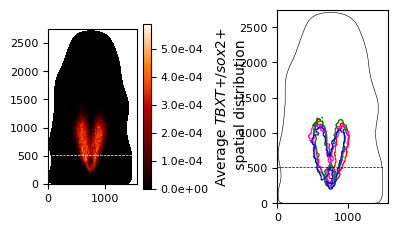

In [ ]:
fig, axes  = plt.subplots(1, 2, figsize=(4, 2.5))

#Diplay density plot

# Display the density of TBXT_SOX2_pos cells
# Heatmap plot
heatmap = axes[0].imshow(SOX2TBXTcounts_resc.T, cmap='gist_heat', origin='lower',
                aspect='equal')
# Masking zero-intensity areas
mask_zero_int = mask_zero_resc.astype(float)
mask_zero_int[mask_zero_resc] = 1
mask_zero_int[mask_zero_resc] = np.nan
axes[0].imshow(mask_zero_int, cmap='Greys', origin='lower', interpolation='none')
axes[1].imshow(mask_zero_int, cmap='Greys', origin='lower', interpolation='none')

axes[1].contour(mask_zero_resc, colors = 'black', origin='lower', linewidths=0.4, levels=[0.5],
                aspect='equal')

#get out colour scheme
colors = ['red', 'magenta', 'green', 'blue']

# Add the black outline for the positive regions
for idx, outline in enumerate(SOX2TBXT_outlines_resc):

    axes[1].contour(outline.T, levels=[0.9], colors= colors[idx], linewidths=0.8, origin='lower')


#Add lines to denote midline and node
axes[0].hlines(chick_ant_limit_sc, 0, chick_rgb_img.shape[1], colors='white', linestyles='dashed', linewidth=0.5)

axes[1].hlines(chick_ant_limit_sc, 0, chick_rgb_img.shape[1], colors='black', linestyles='dashed', linewidth=0.5)
# Add a colorbar linked to the heatmap
cbar = fig.colorbar(heatmap, ax=axes[0], shrink=0.8)  # Smaller colorbar
cbar.set_label(f'Average $TBXT$+/$sox2$+\n spatial distribution')

# Change colorbar to scientific notation (e-3)
formatter = ticker.FuncFormatter(lambda x, _: f'{x:.1e}')
cbar.formatter = formatter
cbar.update_ticks()
plt.tight_layout()
#save figure


plt.show()



#### Process mouse epiblast

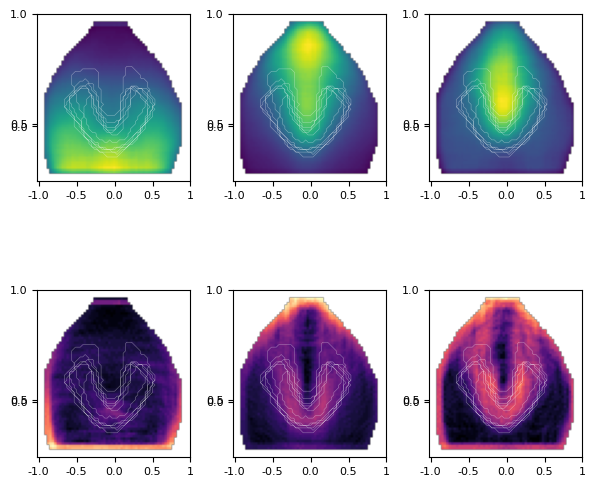

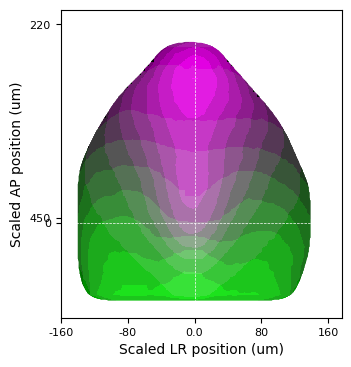

In [ ]:
# Filter epiblast cells
epi_nuc = SP_4_mouse[(SP_4_mouse['Epiblast'] >= 0) ]

# Define columns for scaling and position
x_col, y_col = 'Scaled_Rel_LR_Position', 'Rel_AP_SP_position'

# Scale position coordinates
ant_limit = abs(epi_nuc[y_col].min())
LR_mid = abs(epi_nuc[x_col].min())

#Store the length scales
PS_length = epi_nuc[y_col].max()
LR_length = epi_nuc[x_col].max() + abs(epi_nuc[x_col].min()) 

epi_nuc[y_col] -= epi_nuc[y_col].min()
epi_nuc[x_col] -= epi_nuc[x_col].min() 

# Configuration settings
channels = ['SOX2', 'TBXT', 'TBX6']
embryos = [1, 2, 3, 4,5,6]
scale, pad, ant_cut = 5,50, 0
img_shape = (int(epi_nuc[x_col].max() / scale), int(epi_nuc[y_col].max() / scale))
LR_mid, ant_limit = int(LR_mid / scale), (ant_limit // scale) - ant_cut
post_lim = int(epi_nuc[y_col].max() / scale) - ant_cut
APmid = post_lim - ant_limit

# Initialize storage
avg_imgs = {channel: np.zeros(img_shape) for channel in channels}
counts = {channel: np.zeros(img_shape) for channel in channels}
all_counts = np.zeros(img_shape)
SOX2TBXTcounts = np.zeros(img_shape)
SOX2TBXT_outlines = []
footprint = np.ones((10, 10))

# Process each embryo
for embryo in embryos:
    temp = epi_nuc[epi_nuc['Techrep'] == embryo].copy().dropna(subset=[x_col, y_col] + channels)

    # Count SOX2/TBXT positive cells
    temp_st = temp[temp['NMPROI']==1]
    x_bins, y_bins = (temp_st[x_col] / scale).astype(int), (temp_st[y_col] / scale).astype(int)
    count = np.zeros(img_shape)
    np.add.at(count, (x_bins-1, y_bins-1), 1)
    valid = count > 0
    count[valid] /= len(temp_st)

    # Smooth and outline the SOX2/TBXT positive region
    pos_region = filters.gaussian(count > 0, sigma=1) > 0.4
    SOX2TBXT_outlines.append(pos_region)
    SOX2TBXTcounts += count

    # Bin and average channel data
    x_bins, y_bins = (temp[x_col] / scale).astype(int), (temp[y_col] / scale).astype(int)
    np.add.at(all_counts, (x_bins-1, y_bins-1), 1)

    for channel in channels:
        img, count = np.zeros(img_shape), np.zeros(img_shape)
        np.add.at(img, (x_bins-1, y_bins-1), temp[channel])
        np.add.at(count, (x_bins-1, y_bins-1), 1)
        valid = count > 0
        img[valid] /= count[valid]
        avg_imgs[channel] += img
        counts[channel] += valid

# Finalize averages
for channel in channels:
    valid = counts[channel] > 0
    avg_imgs[channel][valid] /= len(embryos)
SOX2TBXTcounts /= len(embryos)

# Create epiblast mask
mask_zero = np.pad(all_counts > 0, ((pad, pad), (pad, pad)), constant_values=0)
mask_zero = filters.gaussian(mask_zero, sigma=2) > 0.9
mask_zero = mask_zero.T

#Store images for later
channel_imgs = []

# Display channel images
fig, axes = plt.subplots(2, 3, figsize=(6, 6))
for idx, channel in enumerate(channels):
    image = np.pad(avg_imgs[channel].T, ((pad, pad), (pad, pad)), constant_values=0)
    image = exposure.rescale_intensity(image, in_range='image', out_range=(0, 1))
    image = filters.rank.mean_bilateral(image, footprint=footprint, s0=500, s1=500).astype(float)

    grad = np.gradient(image, edge_order=0)
    grad_mag = np.sqrt(grad[0]**2 + grad[1]**2)

    image[~mask_zero], grad_mag[~mask_zero] = np.nan, np.nan
    image, grad_mag = image[ant_cut:][pad:-pad, pad:-pad], grad_mag[ant_cut:][pad:-pad, pad:-pad]

    channel_imgs.append(image)

    axes[0, idx].imshow(image, origin='lower', cmap='viridis')
    axes[1, idx].imshow(grad_mag, origin='lower', cmap='magma')

    for outline in SOX2TBXT_outlines:
        outline = outline.T[ant_cut:]
        for ax in [axes[0, idx], axes[1, idx]]:
            ax.contour(outline, levels=[0.5], colors='white', linewidths=0.4, alpha=0.4)
            ax.set_xticks([0, LR_mid/2, LR_mid, image.shape[1] - LR_mid/2, image.shape[1]])
            ax.set_xticklabels([-1.0, -0.5, 0.0, 0.5, 1])
            ax.set_yticks([ant_limit, (post_lim-ant_limit)/2 + ant_cut, post_lim])
            ax.set_yticklabels([0.0, 0.5, 1.0])


plt.tight_layout()
# plt.savefig(os.path.join(proj_dir, 'Figures', 'TF global gradient and NMP roi outline.pdf'), format='pdf', dpi=300)

plt.show()

#remove padding of the mask and cut
mask_zero = mask_zero[ant_cut:]
mask_zero = mask_zero[pad:-pad, pad:-pad]


# Assuming channel_imgs contains three 2D grayscale images: [channel1, channel2, channel3]
channel1, channel2, channel3 = channel_imgs

#resized image 
channel1 = ski.transform.rescale(channel1, scale, anti_aliasing=True)
channel2 = ski.transform.rescale(channel2, scale, anti_aliasing=True)
channel3 = ski.transform.rescale(channel3, scale, anti_aliasing=True)

mask_zero_resc = ski.transform.rescale(mask_zero, scale)

#smooth the mask
mask_zero_resc = ski.filters.gaussian(mask_zero_resc, sigma=15, mode='constant', cval=0)
mask_zero_resc = mask_zero_resc > 0.5

#Set nans to 0
channel1[np.isnan(channel1)] = 0
channel2[np.isnan(channel2)] = 0
channel3[np.isnan(channel3)] = 0


channel1[~mask_zero_resc] = np.nan
channel2[~mask_zero_resc] = np.nan
channel3[~mask_zero_resc] = np.nan

#Set mask where image is nan
maskNan = np.isnan(channel1)
bins = 10
# #Digitize the image channels into 10 bins
channel1 = np.digitize(channel1, np.linspace(np.nanmin(channel1), np.nanmax(channel1),bins)).astype(float)
channel2 = np.digitize(channel2, np.linspace(np.nanmin(channel2), np.nanmax(channel2), bins)).astype(float)
channel3 = np.digitize(channel3, np.linspace(np.nanmin(channel3), np.nanmax(channel3), bins)).astype(float)

channel1[maskNan] = np.nan
channel2[maskNan] = np.nan
channel3[maskNan] = np.nan


# Normalize each channel if they aren’t already between 0 and 1
channel1 = (channel1 - np.nanmin(channel1)) / np.nanmax(channel1- np.nanmin(channel1))
channel2 = (channel2 - np.nanmin(channel2)) / np.nanmax(channel2- np.nanmin(channel2))
channel3 = (channel3 - np.nanmin(channel3)) / np.nanmax(channel3- np.nanmin(channel3))


# Map each channel to its respective color
blue = np.stack([np.zeros_like(channel3), np.zeros_like(channel3), channel3], axis=2)   # Blue
green = np.stack([np.zeros_like(channel1), channel1, np.zeros_like(channel1)], axis=2) # Green
magenta = np.stack([channel2, np.zeros_like(channel2), channel2], axis=2)             # Magenta

# Combine them by adding the colors together
mous_rgb_image = np.clip(green + magenta , 0, 1)  # Clip to avoid overflow

#Scale the custom ticks by the upscaling (20)
ms_ant_limit_sc = ant_limit * scale
ms_LR_mid_sc = LR_mid * scale
post_lim_sc = post_lim * scale
ant_cut_sc = ant_cut * scale

# Create a figure for the mouse RGB image
fig, axes = plt.subplots(1, 1, figsize=(4, 4))

# Display the mouse RGB image with outlines
axes.imshow(mous_rgb_image, origin='lower', interpolation='nearest')

axes.set_xticks([0, ms_LR_mid_sc/2,ms_LR_mid_sc, channel1.shape[1] - ms_LR_mid_sc/2, channel1.shape[1]])        # Custom x-axis ticks
axes.set_xticklabels([round_to_10(-(LR_length/2)),
                       round_to_10(-(LR_length/4)), 
                       0.0, 
                       round_to_10(LR_length/4), 
                       round_to_10(LR_length/2)])
axes.contour(maskNan, levels=[0.5], colors='white', linewidths=6)
ymid = (post_lim_sc-ms_ant_limit_sc)/2 + ant_cut_sc/2
 
axes.set_yticks([ms_ant_limit_sc, ymid, post_lim_sc ])        # Custom x-axis ticks
axes.set_yticklabels([0, int(PS_length/scale)*10, int(PS_length/10)*10])

#set xy labels
axes.set_xlabel('Scaled LR position (um)')
axes.set_ylabel('Scaled AP position (um)')
axes.hlines(ms_ant_limit_sc, 0, channel1.shape[1], colors='white', linestyles='dashed', linewidth=0.5)
axes.vlines(ms_LR_mid_sc, 0, channel1.shape[0], colors='white', linestyles='dashed', linewidth=0.5)
#set background color to black
plt.show()

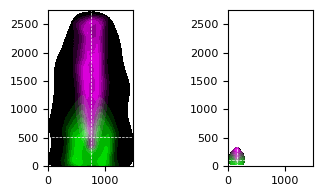

In [ ]:
#Plot chick and mouse next to each other on the same scale
ylims = (0, chick_rgb_img.shape[0])
xlims = (0, chick_rgb_img.shape[1])
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].imshow(chick_rgb_img, origin='lower', interpolation='nearest')
axes[0].set_xlim(xlims)
axes[0].set_ylim(ylims)
axes[0].hlines(chick_ant_limit_sc, 0, chick_rgb_img.shape[1], colors='white', linestyles='dashed', linewidth=0.5)
axes[0].vlines(chick_LR_mid_sc, 0, chick_rgb_img.shape[0], colors='white', linestyles='dashed', linewidth=0.5)
#plot node streak border

axes[1].imshow(mous_rgb_image, origin='lower', interpolation='nearest')
axes[1].hlines(ms_ant_limit_sc, 0, mous_rgb_image.shape[1], colors='white', linestyles='dashed', linewidth=0.5)
axes[1].vlines(ms_LR_mid_sc, 0, mous_rgb_image.shape[0], colors='white', linestyles='dashed', linewidth=0.5)

axes[1].set_xlim(xlims)
axes[1].set_ylim(ylims)

#move plots closer together
plt.subplots_adjust(hspace=100)



plt.tight_layout()


## plot chick and mouse in relative space

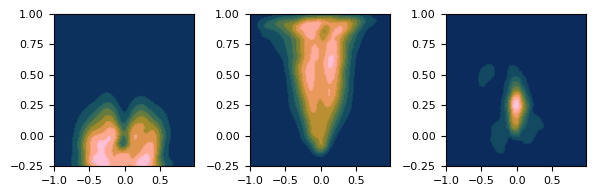

In [ ]:
# Isolate the Chick epiblast cells for further analysis
epi_nuc = chick_cells[chick_cells['epi_prediction'] == 1]

# Assuming epi_nuc is a DataFrame
channels = ['SOX2', 'TBXT', 'MSGN1']
ycol = 'Rel_AP_position'
xcol = 'Rel_LR_position'

# Set msgn1 threshold
msgn1_thresh = 0.3
epi_nuc['MSGN1'] -= msgn1_thresh
epi_nuc.loc[epi_nuc['MSGN1'] < 0.01, 'MSGN1'] = 0.01

# Define binning
n_bins = 80
x_bins = np.linspace(epi_nuc[xcol].min(), epi_nuc[xcol].max(), n_bins)
y_bins = np.linspace(epi_nuc[ycol].min(), epi_nuc[ycol].max(), n_bins)

# Store average data for each channel
channel_avg_data = {}

# Bin data and average per replicate (e.g., per embryo)
for channel in channels:
    binned_data = []
    for embryo in epi_nuc['embryo'].unique():
        embryo_data = epi_nuc[epi_nuc['embryo'] == embryo]
        hist2d, _, _ = np.histogram2d((embryo_data[xcol]), 
                                        embryo_data[ycol], 
                                        bins=[x_bins, y_bins], 
                                        weights=embryo_data[channel])
        count, _, _ = np.histogram2d(embryo_data[xcol], 
                                    embryo_data[ycol], 
                                    bins=[x_bins, y_bins])
        avg = np.divide(hist2d, count, where=count != 0)
        binned_data.append(avg)

    # Average across embryos and store
    avg_data = np.nanmean(binned_data, axis=0)
    # Apply local mean smoothing
    smoothed_data = uniform_filter(avg_data, size=5, cval=np.nan)
    channel_avg_data[channel] = smoothed_data

#Create mask outline for SOX2/TBXT positive cells

outlines = []
for idx, embryo in enumerate(epi_nuc['embryo'].unique()):
    sox2tpos = epi_nuc[(epi_nuc['embryo'] == embryo) & (epi_nuc['TBXT_SOX2_pos'])]

    count, _,_ = np.histogram2d((sox2tpos[xcol]),
                                 sox2tpos[ycol], 
                                 bins=[x_bins, y_bins])
    
    # Smooth and threshold the count data
    pos_region = filters.gaussian(count > 0, sigma=1) > 0.9

    outlines.append(pos_region)

# Create filled contour plots for all channels
fig, axes = plt.subplots(1,3 , figsize=(6, 2))
for ax, channel in zip(axes, channels):
    X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])
    CS = ax.contourf(X, Y, channel_avg_data[channel].T, cmap=cmc.batlow, levels=10)
    CS = ax.contour(X, Y, channel_avg_data[channel].T, cmap=cmc.batlow, levels=10, linewidths=0.5)



    ax.set_ylim(-0.25, 1)

X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])

plt.tight_layout()
plt.show()


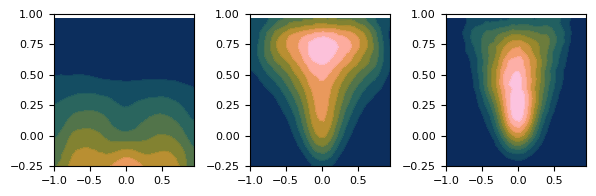

In [ ]:
# Isolate the mouse epiblast cells for further analysis
epi_nuc = SP_4_mouse[(SP_4_mouse['Epiblast'] >= 0)]
# Assuming epi_nuc is a DataFrame
channels = ['SOX2', 'TBXT', 'TBX6']
ycol = 'NormY'
xcol = 'Rel_LR_position'

#Set thresholds
epi_nuc['SOX2'] = epi_nuc['SOX2'] - 1200
epi_nuc.loc[epi_nuc['SOX2'] < 0.01, 'SOX2'] = 0.01

epi_nuc['TBXT'] = epi_nuc['TBXT'] - 2400
epi_nuc.loc[epi_nuc['TBXT'] < 0.01, 'TBXT'] = 0.01

epi_nuc['TBX6'] = epi_nuc['TBX6'] - 1800
epi_nuc.loc[epi_nuc['TBX6'] < 0.01, 'TBX6'] = 0


# Define binning
n_bins = 40
x_bins = np.linspace(epi_nuc[xcol].min(), epi_nuc[xcol].max(), n_bins)
y_bins = np.linspace(epi_nuc[ycol].min(), epi_nuc[ycol].max(), n_bins)
smoothing = 6


# Store average data for each channel
channel_avg_data = {}

# Bin data and average per replicate (e.g., per embryo)
for channel in channels:
    binned_data = []
    for embryo in epi_nuc['Techrep'].unique():
        embryo_data = epi_nuc[epi_nuc['Techrep'] == embryo]
        hist2d, _, _ = np.histogram2d(embryo_data[xcol], 
                                        embryo_data[ycol], 
                                        bins=[x_bins, y_bins], 
                                        weights=embryo_data[channel])
        count, _, _ = np.histogram2d(embryo_data[xcol], 
                                    embryo_data[ycol], 
                                    bins=[x_bins, y_bins])
        avg = np.divide(hist2d, count, where=count != 0)
        binned_data.append(avg)

    # Average across embryos and store
    avg_data = np.nanmean(binned_data, axis=0)
    # Apply local mean smoothing
    smoothed_data = uniform_filter(avg_data, size=smoothing, cval=np.nan)
    channel_avg_data[channel] = smoothed_data

outlines = []
for idx, embryo in enumerate(epi_nuc['Techrep'].unique()):
    sox2tpos = epi_nuc[(epi_nuc['Techrep'] == embryo) & (epi_nuc['NMPROI']==1)]

    count, _,_ = np.histogram2d((sox2tpos[xcol]),
                                 sox2tpos[ycol], 
                                 bins=[x_bins, y_bins])
    
    # Smooth and threshold the count data
    pos_region = filters.gaussian(count > 0, sigma=0.1) > 0.1

    outlines.append(pos_region)

# Create filled contour plots for all channels
fig, axes = plt.subplots(1,3 , figsize=(6, 2))
for ax, channel in zip(axes, channels):
    X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])
    CS = ax.contourf(X, Y, channel_avg_data[channel].T, cmap=cmc.batlow, levels=10)
    CS = ax.contour(X, Y, channel_avg_data[channel].T, cmap=cmc.batlow, levels=10, linewidths=0.5)
    # for outline in outlines:
    #     CS = ax.contour(X, Y, outline.T, colors='white', linewidths=0.5, alpha=0.5)


    ax.set_ylim(-0.25,1)

X, Y = np.meshgrid(x_bins[:-1], y_bins[:-1])
plt.tight_layout()

plt.show()


#### Relative and absolute distance of paraxial mesoderm peak

In [ ]:
# --- Process Mouse Data at SP = 4 ---
sp = 4
mouse_PM_points_rel = []
mouse_PM_points_real = []

epi_nuc = mouse_cells[mouse_cells['SP'] == sp]

# Loop through each embryo to find PM points
for embryo in epi_nuc['SP_Rep'].unique():
    temp = epi_nuc[epi_nuc['SP_Rep'] == embryo]
    temp = temp[temp['log_Smooth_TBX6'] > temp['log_Smooth_TBX6'].quantile(0.99)]

    # Relative AP position
    mouse_PM_points_rel.append(temp['Rel_AP_Position'].mean())

    # Scaled real position
    mouse_PM_points_real.append(temp['Scaled_Rel_AP_Position'].mean())

mouse_PM_points_rel = np.array(mouse_PM_points_rel)
mouse_PM_points_real = np.array(mouse_PM_points_real)

# --- Process Chick Data ---
epi_nuc = chick_cells[chick_cells['epi_prediction'] == 1]
chick_PM_points = []
chick_PM_points_real = []

for embryo in epi_nuc['embryo'].unique():
    temp = epi_nuc[epi_nuc['embryo'] == embryo]
    temp = temp[temp['MSGN1'] > temp['MSGN1'].quantile(0.99)]

    chick_PM_points.append(temp['Rel_AP_position'].mean())
    chick_PM_points_real.append(temp['AP_noto'].mean() )

chick_PM_points = np.array(chick_PM_points)
chick_PM_points_real = np.array(chick_PM_points_real)

# --- Calculate Means and Confidence Intervals ---
def mean_CI(data):
    mean = data.mean()
    ci = 1.96 * data.std() / np.sqrt(len(data))
    return mean, ci

mouse_mean_rel, mouse_CI_rel = mean_CI(mouse_PM_points_rel)
mouse_mean_real, mouse_CI_real = mean_CI(mouse_PM_points_real)

chick_mean_rel, chick_CI_rel = mean_CI(chick_PM_points)
chick_mean_real, chick_CI_real = mean_CI(chick_PM_points_real)

# --- Generate Jittered X Values for Plotting ---
x_chick = np.zeros(len(chick_PM_points)) + np.random.normal(0, 0.05, size=len(chick_PM_points))
x_mouse = np.ones(len(mouse_PM_points_real)) + np.random.normal(0, 0.05, size=len(mouse_PM_points_real))

# --- Plot Real AP Positions ---
plt.figure(figsize=(1, 2))
plt.scatter(0, chick_mean_real, color='red', s=10)
plt.errorbar(0, chick_mean_real, yerr=chick_CI_real, fmt='o', capsize=5, color='black', linewidth=1)
plt.scatter(x_chick, chick_PM_points_real, color='red', s=10)

plt.scatter(x_mouse, mouse_PM_points_real, color='blue', s=10)
plt.scatter(1, mouse_mean_real, color='blue', s=10)
plt.errorbar(1, mouse_mean_real, yerr=mouse_CI_real, fmt='o', capsize=5, color='black', linewidth=1)

plt.xticks([0, 1], ['Chick', 'SP4'])
plt.xlim(-1, 2)
plt.ylim(0, chick_cells['AP_noto'].max())

# --- Plot Relative AP Positions ---
plt.figure(figsize=(1, 2))
plt.scatter(0, chick_mean_rel, color='red', s=10)
plt.errorbar(0, chick_mean_rel, yerr=chick_CI_rel, fmt='o', capsize=5, color='black', linewidth=1)
plt.scatter(x_chick, chick_PM_points, color='red', s=10)

plt.scatter(x_mouse, mouse_PM_points_rel, color='blue', s=10)
plt.scatter(1, mouse_mean_rel, color='blue', s=10)
plt.errorbar(1, mouse_mean_rel, yerr=mouse_CI_rel, fmt='o', capsize=5, color='black', linewidth=1)

plt.xticks([0, 1], ['Chick', 'SP4'])
plt.xlim(-1, 2)
plt.ylim(0, 1)
